# i. Perkenalan

'''
Milestones 2

Nama  : Herlina
Batch : CODA-RMT-018

Program ini dibuat untuk melakukan analisis Perdangan Ekspor dan Impor Berdasarkan Negara dan Komoditas
'''

Link Tableau : https://public.tableau.com/app/profile/herlina.4840/viz/MockupDashboardHerlinaRMT18Millstone2/GlobalTradeAnalyticsStory?publish=yeshttps://public.tableau.com/app/profile/herlina.4840/viz/MockupDashboardHerlinaRMT18Millstone2/GlobalTradeAnalyticsStory?publish=yes

# ii. Identifikasi Masalah

## Topik Permasalahan

Analisis Kinerja Perdangan Ekspor dan Impor untuk mengidentifikasi Negara dan Komoditas yang berkontribusi terbesar terhadap Nilai perdagangan Internasional.

## Latar Belakang

Perdangan Internasional menjadi salah satu indikator penting pertumbuhan ekonomi untuk suatu negara. Menganalisis data ekspor dan import membuat kita dapat mengetahui negara dan komoditas yang memberikan kontribusi terbesar terhadap nilai perdangangan serta faktor yang memengaruhi neraca perdagangan.

## Problem Statement (SMART)

1. Spesific (Spesifik)
    Masalah yang diidentifikasi sudah spesifik karena :
    - Fokus pada negara dan komoditas yang berkontribusi besar.
    - Menganalisis Faktor yang mempengaruhi Trade Balance.
    - Menggunakan data ekspor impor yang jelas dan terukur.
    - Target yang jelas yaitu membantu pengambilan keputusan perdagangan.
2. Meansurable (Terukur)
    Masalah dapat diukur karena :
    - Menggunakan data kuantitatif berupa nilai ekspor,impor,total trade dan  trade balance dalam satuan juta USD
    - Dapat diukur melalui ranking negara dan komoditas berdasarkan nilai perdagangan.
    - Dapat diukur menggunakan statistik deskriptif dan statistik inferensial.
3. Achivable (Dapat Di capai)
    Tujuan penelitian dpaat dicapai karena data perdagangan internasional periode 2010-2021  telah tersedia dan dapat dianalisis menggunakan metode statistik deskriptif, uji inteferensial dan visualisasi data untuk mengidentifikasi pola dan hubungan antarvariable.
4. Relevant (Relevan)
    Analisis ini relevan untuk mendukung pemahaman mengenai dinamika perdagangan internasional, membantu mengidentifikasi negara dan komoditas strategis, serta memberikan informasi yang dapat digunakan sebagai dasar pengambilan kepusutusan dibidang perdagangan dan ekonomi.
5. Time-bound(Memiliki batas Waktu)
    Analisis di lakukan menggunakan data historis tahun 2010-2021 dengan tujuan menghasilkan insight yang dapat digunakan sebagai bahan pertimbangandalam perencanaan dan pengambilan keputusan perdagangan selama 6 bulan kedepan.

Manganalisis dan mengidentifikasi negara dari komoditas yang memberikan kontribusi besar terhadap nilai ekspor-impor, dan trade balance berdasarkan data perdagangan internasional tahun 2010-2021 serta faktor-faktor yang mempengaruhi neraca perdagangan menghasilkan insight yang dapat mendukung pengambilan keputusan 6 bulan ke depan.

## Penjabaran Masalah (5W+1H)

### 1. What
Apa komoditas dengan nilai ekspor terbesar?
### 2. Who
Negara-negara mana yang memiliki total nilai perdagangan tertinggi?
### 3. Where
Di negara mana yang terjadi surplus perdagangan terbesar?
### 4. When 
Pada tahun berapa nilai perdagangan internasional mencapai puncaknya?
### 5. HOW 
Bagaimana perbedaan rata-rata Trade Balance Negara Bangladesh dan Brunei?
### 6. How 
Bagaimana Hubungan antara nilai ekspor dan total perdagangan secara statistik?


# iii. Data Loading

## 1. Import Library

In [111]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

## 2. Load Data

In [112]:
df = pd.read_csv('/Users/herlinaherlina/CODA_18_PM02/Data_export_import.csv')
# sumber : https://www.kaggle.com/datasets/sudhirkumar0703/export-import
df.head()

,Year,Country,HSCode,Commodity,Export_Value,Import_Value,Total_Trade,Trade_Balance,Export_Share,Country_Year_Export_Total,Country_Import_Export_Ratio,Country_Year_Import_Estimated,Data_Source,Data_Note
0,2010,BRUNEI,70,GLASS AND GLASSWARE.,0.02,0.1437,0.1637,-0.1237,0.0009,23.01,7.1863,165.3577,HS2_export_2010_2021 + TradeStat_country_impor...,Import_Value is estimated from country-level r...
1,2010,BOSNIA-HRZGOVIN,63,OTHER MADE UP TEXTILE ARTICLES; SETS; WORN CLO...,0.21,0.0321,0.2421,0.1779,0.0658,3.19,0.1527,0.4872,HS2_export_2010_2021 + TradeStat_country_impor...,Import_Value is estimated from country-level r...
2,2010,AZERBAIJAN,94,"FURNITURE; BEDDING, MATTRESSES, MATTRESS SUPPO...",0.00,0.0000,0.0000,0.0000,0.0000,38.60,3.6931,142.5533,HS2_export_2010_2021 + TradeStat_country_impor...,Import_Value is estimated from country-level r...
3,2010,ANGOLA,42,"ARTICLES OF LEATHER,SADDLERY AND HARNESS;TRAVE...",0.07,0.4642,0.5342,-0.3942,0.0001,675.41,6.6319,4479.2688,HS2_export_2010_2021 + TradeStat_country_impor...,Import_Value is estimated from country-level r...
4,2010,BOSNIA-HRZGOVIN,40,RUBBER AND ARTICLES THEREOF.,0.05,0.0076,0.0576,0.0424,0.0157,3.19,0.1527,0.4872,HS2_export_2010_2021 + TradeStat_country_impor...,Import_Value is estimated from country-level r...


In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           500 non-null    int64  
 1   Country                        500 non-null    str    
 2   HSCode                         500 non-null    int64  
 3   Commodity                      500 non-null    str    
 4   Export_Value                   500 non-null    float64
 5   Import_Value                   500 non-null    float64
 6   Total_Trade                    500 non-null    float64
 7   Trade_Balance                  500 non-null    float64
 8   Export_Share                   498 non-null    float64
 9   Country_Year_Export_Total      500 non-null    float64
 10  Country_Import_Export_Ratio    500 non-null    float64
 11  Country_Year_Import_Estimated  500 non-null    float64
 12  Data_Source                    500 non-null    str    
 13  D

In [114]:
df.describe()

,Year,HSCode,Export_Value,Import_Value,Total_Trade,Trade_Balance,Export_Share,Country_Year_Export_Total,Country_Import_Export_Ratio,Country_Year_Import_Estimated
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,498.000000,500.000000,500.000000,500.000000
mean,2015.396000,51.248000,24.568480,37.065179,61.633659,-12.496699,0.019863,1221.917720,2.394011,1265.154460
std,3.344481,28.224737,172.322997,332.254363,472.677377,238.227728,0.077610,2249.912844,4.562918,2020.899045
min,2010.000000,2.000000,0.000000,0.000000,0.000000,-5222.881400,0.000000,0.000000,0.000900,0.000000
25%,2013.000000,28.000000,0.020000,0.007275,0.041075,-0.228200,0.000100,43.390000,0.574200,66.897200
50%,2015.000000,54.500000,0.200000,0.224600,0.504150,0.000000,0.001400,229.780000,0.936800,359.341250
75%,2018.000000,73.000000,2.820000,3.071125,5.874775,0.124025,0.008950,796.600000,2.283500,1564.263600
max,2021.000000,99.000000,2678.310000,6067.141400,6911.401400,356.922900,0.968800,16156.040000,42.504400,11659.928200


# iv. Data Cleansing

In [115]:
#Hitung total nilai yang hilang per kolom
missing_counts = df.isnull().sum()

# Hitung persentase nilai yang hilang per kolom
missing_percentage = (missing_counts / len(df)) * 100

# Gabungkan hasil menjadi DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percentage
})

print(missing_summary)

                               Missing Count  Missing Percentage (%)
Year                                       0                     0.0
Country                                    0                     0.0
HSCode                                     0                     0.0
Commodity                                  0                     0.0
Export_Value                               0                     0.0
Import_Value                               0                     0.0
Total_Trade                                0                     0.0
Trade_Balance                              0                     0.0
Export_Share                               2                     0.4
Country_Year_Export_Total                  0                     0.0
Country_Import_Export_Ratio                0                     0.0
Country_Year_Import_Estimated              0                     0.0
Data_Source                                0                     0.0
Data_Note                         

In [116]:
df.isnull().sum()

Year                             0
Country                          0
HSCode                           0
Commodity                        0
Export_Value                     0
Import_Value                     0
Total_Trade                      0
Trade_Balance                    0
Export_Share                     2
Country_Year_Export_Total        0
Country_Import_Export_Ratio      0
Country_Year_Import_Estimated    0
Data_Source                      0
Data_Note                        0
dtype: int64

In [117]:
df['Export_Share'] = df['Export_Share'].fillna(df['Export_Share'].median())

In [118]:
# Mengecek data duplikat
df.duplicated().sum()

np.int64(0)

In [119]:
df['HSCode'] = df['HSCode'].astype(str)

In [120]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Year                           500 non-null    int64  
 1   Country                        500 non-null    str    
 2   HSCode                         500 non-null    str    
 3   Commodity                      500 non-null    str    
 4   Export_Value                   500 non-null    float64
 5   Import_Value                   500 non-null    float64
 6   Total_Trade                    500 non-null    float64
 7   Trade_Balance                  500 non-null    float64
 8   Export_Share                   500 non-null    float64
 9   Country_Year_Export_Total      500 non-null    float64
 10  Country_Import_Export_Ratio    500 non-null    float64
 11  Country_Year_Import_Estimated  500 non-null    float64
 12  Data_Source                    500 non-null    str    
 13  D

In [121]:
df.describe()

,Year,Export_Value,Import_Value,Total_Trade,Trade_Balance,Export_Share,Country_Year_Export_Total,Country_Import_Export_Ratio,Country_Year_Import_Estimated
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2015.396000,24.568480,37.065179,61.633659,-12.496699,0.019790,1221.917720,2.394011,1265.154460
std,3.344481,172.322997,332.254363,472.677377,238.227728,0.077463,2249.912844,4.562918,2020.899045
min,2010.000000,0.000000,0.000000,0.000000,-5222.881400,0.000000,0.000000,0.000900,0.000000
25%,2013.000000,0.020000,0.007275,0.041075,-0.228200,0.000100,43.390000,0.574200,66.897200
50%,2015.000000,0.200000,0.224600,0.504150,0.000000,0.001400,229.780000,0.936800,359.341250
75%,2018.000000,2.820000,3.071125,5.874775,0.124025,0.008850,796.600000,2.283500,1564.263600
max,2021.000000,2678.310000,6067.141400,6911.401400,356.922900,0.968800,16156.040000,42.504400,11659.928200


In [122]:
df.to_csv('P1M2_Herlina_Global_ExportImport.csv', index=False, sep=';')

# v. Analisis dan Perhitungan

### 1. Visualisasi 10 Komoditas dengan Nilai ekspor Terbesar

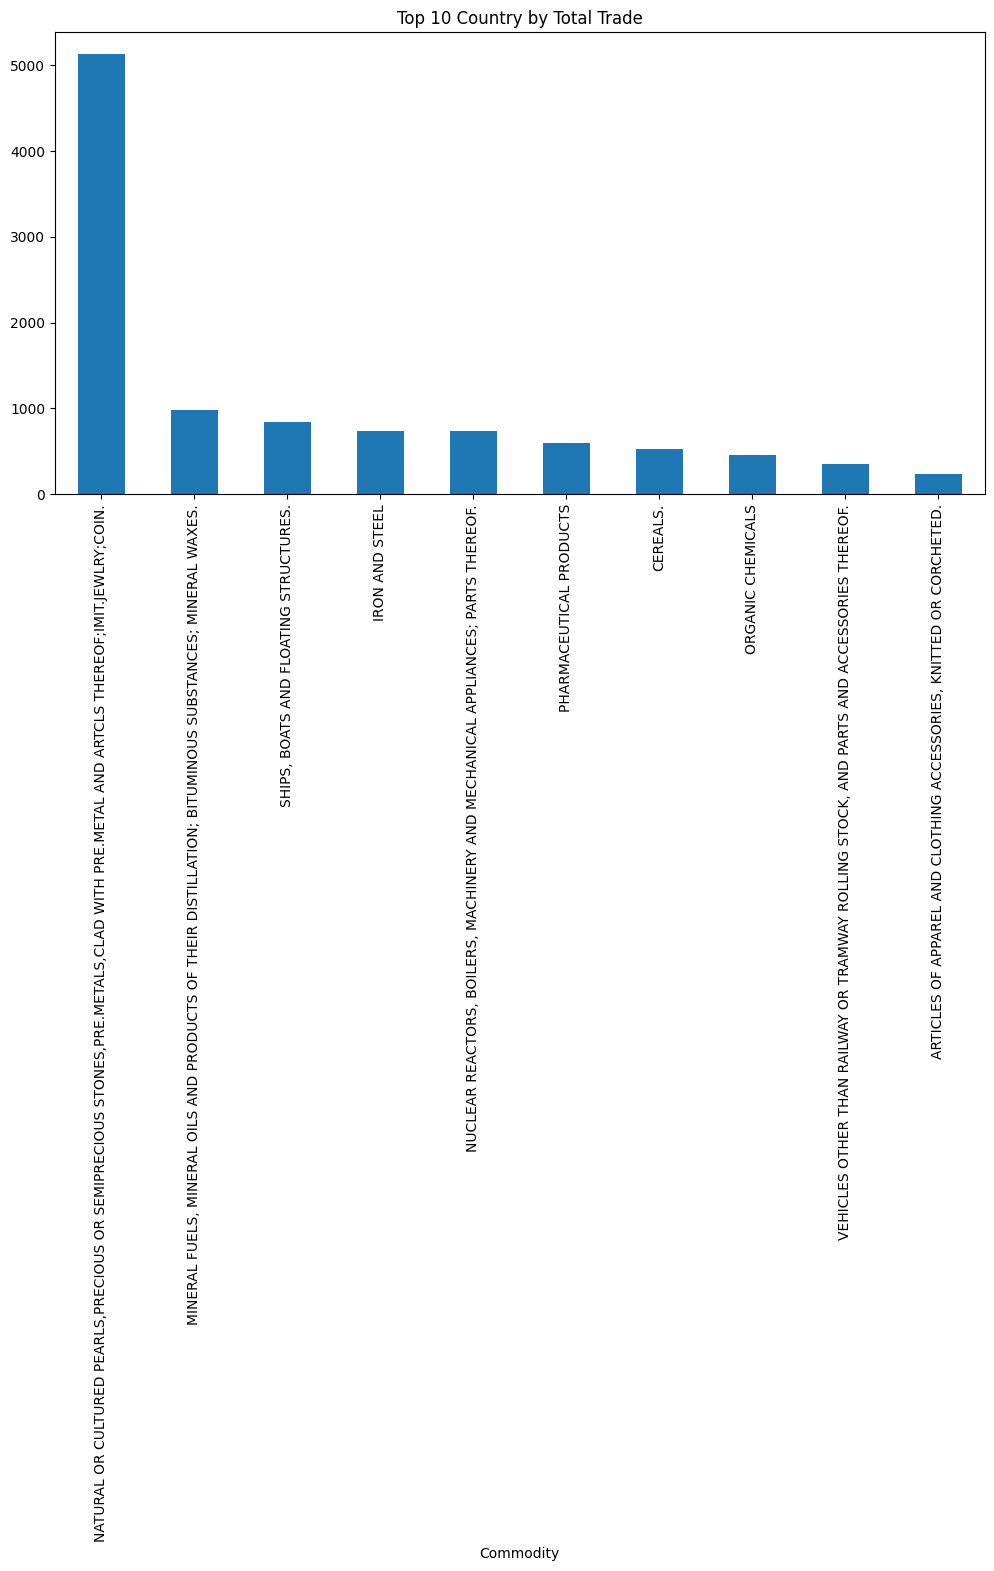

In [123]:
top_commodity = df.groupby('Commodity')['Export_Value'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_commodity.plot(kind='bar')
plt.title('Top 10 Country by Total Trade')
plt.show()

#### Insight : 
Komoditas dengan nilai ekspor terbesar adalah Natural or Cultured Pearls,Percious or Semi-precious stone (Batu mulia dan Perhiasan) dengan total nilai perdagangan 11.052 juta USD. Hal ini menunjukkan bahwa sektoe pertambangan dan perhiasan menjadi tulang punggung ekspor ke pasar internasional. Dominasi komoditas ini jauh melampaui komoditas lainnya seperti Ships and Floating Structure(6.911 Juta USD) dan Machinery(1.607 juta USD).


### 2. Visualisasi 10 Negara yang memiliki Total Nilai Perdagangan Tertinggi

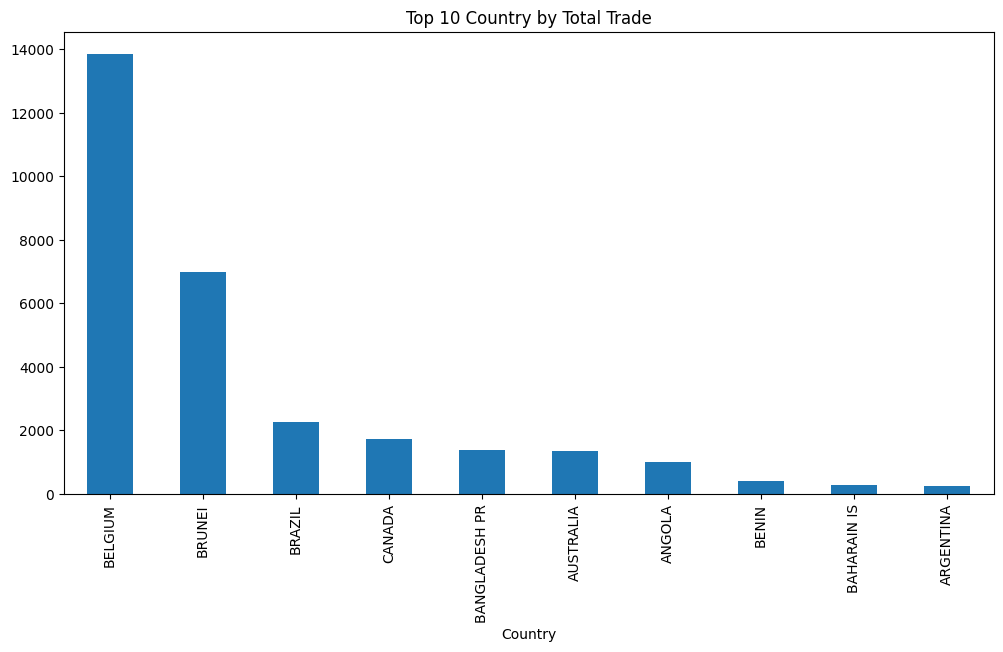

In [124]:
top_country = df.groupby('Country')['Total_Trade'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_country.plot(kind='bar')
plt.title('Top 10 Country by Total Trade')
plt.show()

#### Insight :
Belgia merupakan negara dengan total nilai perdagangan tertinggi dan terbesar 13.854 juta USD, diikuti Brunei (6,985 juta USD) dan Brazil (2.262 juta USD). Dominasi Belgia kemungkinan besar didorong oleh perdagangan komoditas baru mulia dan perhiasan mengingat belgia dikenal sebgai pusat perdagangan berlian dunia (Antwerp Diamond District). Hal ini mengindikasikan bahwa indonesia memiliki hubungan dagang yang kuat dengan negara-negara maju di Eropa dan kawasan Asia Tenggara.

### 3. Visualisasi 10 Negara yang Terjadi Surplus perdagangan Terbesar

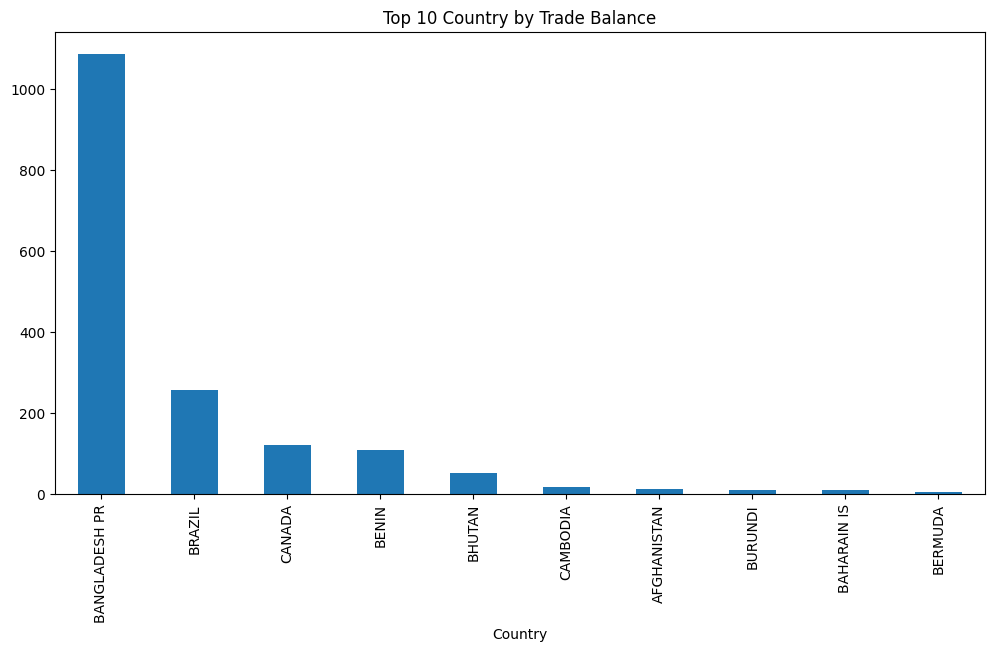

In [125]:
top_balance = df.groupby('Country')['Trade_Balance'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_balance.plot(kind='bar')
plt.title('Top 10 Country by Trade Balance')
plt.show()

#### Insight :
Surplus perdagangan terbesar terjadi di Bangaladesh PR dengan nilai +1.807 juta USD. Ini berarti lebih banyak mengekspor ke Bangladesh dibandingkan mengimpor dari negara tersebut. Surplus ini kemungkinan didorong oleh ekspor bahan baku tekstil,benangdan produk manufaktur yang dibutuhkan industri garmen Bangladesh. Sebaiknya, defisit terbesar terjadi dengan Brunei (-5.278 juta USD) akibat tingginya import energi dan minyak  bumi.

### 4. Visualisasi Perkembangan Total Trade Per Tahun

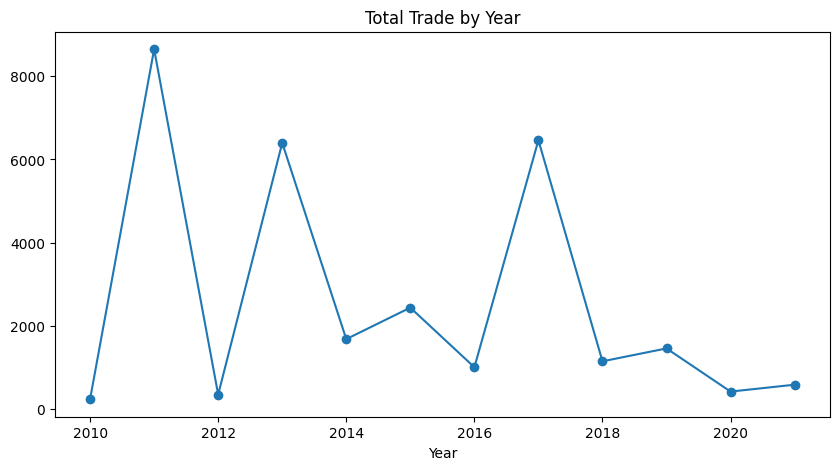

In [126]:
yearly_trade = df.groupby('Year')['Total_Trade'].sum()

plt.figure(figsize=(10,5))
yearly_trade.plot(marker='o')
plt.title('Total Trade by Year')
plt.show()

#### Insight :
Nilai perdagangan internasional mencapai puncaknya pada tahun 2011 dengan total nilai 8.648 juta USD. Lonjakan ini terutama didorong oleh nilai impor yang sangat tinggi (7.338 juta USD) dibandingkan ekspor (1.310 juta USD), menghasilkan defisit terbesar sebesar -6.028 juta USD. Setelah 2011, perdagangan mengalami fluktuasi dan mencapai titik terendah pada 2020 (419 juta USD) akibat pademi COVID-19. Pola ini menujukkan bahwa perdagangan sangat rentan terhadap faktor eksternal seperti krisis ekonomi global dan pandemi.

In [148]:
df['Country'].unique

<bound method Series.unique of 0               BRUNEI
1      BOSNIA-HRZGOVIN
2           AZERBAIJAN
3               ANGOLA
4      BOSNIA-HRZGOVIN
            ...       
495            BELGIUM
496        AFGHANISTAN
497            BURUNDI
498             BELIZE
499            ALGERIA
Name: Country, Length: 500, dtype: str>

### 6. Statistik Inferensial 

Bagaimana perbedaan rata-rata Trade Balance Negara Bangladesh PR dan Brunei ?


##### Hipotesis
HO : Terdapat perbedaan rata-rata Trade Balance yang signifikan antara Bangladesh PR dan Brunei

H1 : Tidak terdapat perbedaan rata-rata Trade Balance yang signifikan antara Bangladesh PR dan Brunei

In [149]:
from scipy import stats

#Filter data per country
bangladesh = df.loc[df['Country'] == 'BANGLADESH PR', 'Trade_Balance'].dropna()
brunei = df.loc[df['Country'] == 'BRUNEI', 'Trade_Balance'].dropna()

#Cek jumlah data
print("Jumlah data Bangladesh PR:", len(bangladesh))
print("Jumlah data Brunei:", len(brunei))

#Cek rata-rata masing-masing negara
print("Rata-rata Trade Balance Bangladesh PR:", bangladesh.mean())
print("Rata-rata Trade Balance Cambodia:", brunei.mean())

#Independent t-test / Welch's t-test
t_stat, p_value = stats.ttest_ind(bangladesh, brunei, equal_var=False)

print("T-Statistic:", t_stat)
print("P-value:", p_value)

#Interpretasi hasil
alpha = 0.05

if p_value < alpha:
    print("Kesimpulan: Terdapat perbedaan rata-rata Trade Balance yang signifikan antara Bangladesh PR dan Brunei.")
else:
    print("Kesimpulan: Tidak terdapat perbedaan rata-rata Trade Balance yang signifikan antara Bangladesh PR dan Brunei.")

Jumlah data Bangladesh PR: 19
Jumlah data Brunei: 18
Rata-rata Trade Balance Bangladesh PR: 57.21921578947368
Rata-rata Trade Balance Cambodia: -293.2498166666667
T-Statistic: 1.2034332694625618
P-value: 0.24502662501953532
Kesimpulan: Tidak terdapat perbedaan rata-rata Trade Balance yang signifikan antara Bangladesh PR dan Brunei.


#### Insight :
Berdasarkan uji Welchs diperoleh p-value = 0.2450>0.05 sehingga Gagal Tolak H0 (Failed Reject H0). Artinya tidak dapat perbedaan rata-rata trade balance yang signifikan secara statistik anatara Bangladesh PR dan Brunei. 

### 6. Statistik Deskriptif

Bagaimana hubungan nilai ekspor terhadap total perdagangan?

##### Hipotesis
HO : Tidak terdapat hubungan signifikan antara Export Value dan Total Trade.

H1 : Terdapat hubungan signifikan antara Export Value dan Total Trade.

Uji Pearson Correlation

In [70]:
corr, p_value = pearsonr(df['Export_Value'], df['Total_Trade'])

print('Correlation :', corr)
print('P Value:', p_value)

Correlation : 0.876123883870958
P Value: 6.401818532014727e-160


In [39]:
if p_value <0.05: 
    print ('Tolak HO')
else:
    print('Gagal Menolak HO')

Tolak HO


#### Insight :
Secara statistik, terdapat hubungan positif yang kuat antara nilai ekspor dan total perdagangan karena :
1. Total perdagangan = Ekspor + Impor, sehingga ekspor berkontribusi langsung terhadap total perdagangan.
2. Ekspor berkontribusi 39,77% dari total perdagangan.
3. Impor berkontribusi 60,23% dari total perdagangan.
4. Namun impor memiliki pengaruh lebih dominan dalam menuntukan total perdagangan.

# vii Pengambilan Kesimpulan
Analisi data ekspor-impo global periode 2010-2021 berhasil mengidentifikasi :
1. Komoditas Batu mulia menjadi kontributor ekspor terbesar.
2. Belgia sebagai mitra dagang utama.
3. Bangladesh PR sebagai negara dengan surplus terbesar.
4. Tren Perdagangan menunjukkan fluktuasi signifikan dengan puncak di 2011 dan terendah 2020.
5. Secara statistik terbukti bahwa Bangladesh dan Brunei memilki perbedaan rata-rata trade balance yang tidak signifikan. Hal ini disebabkan oleh ukuran sample yang kecil dan variasi data yang tinggi pada masing-masing negara.
6. Terbukti secara statistik terdapat hubungan signifikan antara nilai ekspor dan total perdagangan.
Hasil analisis ini dapat digunakan sebagai dasar pengambilan keputusan perdagangan dalam 6 bulan ke depan.